In [1]:
!pip install jax jaxlib
!pip install lightkurve
!pip install oktopus

  Obtaining dependency information for numpy>=2.0 from https://files.pythonhosted.org/packages/76/ae/e0265e0163cf127c24c3969d29f1c4c64551a1e375d95a13d32eab25d364/numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Admin\\anaconda3\\anaconda\\Lib\\site-packages\\~2mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



  Obtaining dependency information for numpy>=1.18 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
jax 0.9.0.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.9.0.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, windows
from scipy.optimize import curve_fit

# ---------------------------------------------
# Scaling relations: allows us to predicts the large frequency separation (Δν) from νmax

def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772

def numax_from_delta_nu(dnu):
    return (dnu / 0.263)**(1.0 / 0.772)



# ----------------------------------------------
# Gaussian function to model how strong oscillation detection is as you scan across different trial values of νmax.

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c



#------------------------------------------------
# Sliding window 

def sliding_fft_search(freq, power, numax_grid, k_width=4.0, sep_range=(20,200)):
    df = np.median(np.diff(freq))
    ufreq = np.arange(freq.min(), freq.max(), df)
    upower = np.interp(ufreq, freq, power)
    
    fft_strength = []
    
    for numax_trial in numax_grid:
        dnu_est = delta_nu_from_numax(numax_trial)
        W = k_width * dnu_est
        mask = (ufreq > numax_trial - W/2) & (ufreq < numax_trial + W/2)
        
        if np.sum(mask) < 128:
            fft_strength.append(0.0)
            continue
        
        p = upower[mask] - np.mean(upower[mask])
        p *= windows.hann(len(p))
        
        fft = np.fft.rfft(p)
        fft_freq = np.fft.rfftfreq(len(p), d=df)
        fft_power = np.abs(fft)**2
        
        sep = 1.0 / fft_freq[1:]
        pow_sep = fft_power[1:]
        
        s_mask = (sep > sep_range[0]) & (sep < sep_range[1])
        if np.sum(s_mask) == 0:
            fft_strength.append(0.0)
            continue
        
        i = np.argmax(pow_sep[s_mask])
        strength = pow_sep[s_mask][i] / np.median(pow_sep[s_mask])
        fft_strength.append(strength)
    
    return np.array(fft_strength)



#---------------------------------------
#


def fit_numax(numax_grid, strength, sigma_guess=300, plot=True):
    peak_idx = np.argmax(strength)
    fit_window = 2 * sigma_guess
    
    mask = (numax_grid >= numax_grid[peak_idx] - fit_window) & (numax_grid <= numax_grid[peak_idx] + fit_window)
    x_fit = numax_grid[mask]
    y_fit = strength[mask]

    valid = y_fit > 0
    x_fit = x_fit[valid]
    y_fit = y_fit[valid]

    if len(x_fit) < 5:
        return numax_grid[peak_idx], 0.0, None

    p0 = [np.max(y_fit), numax_grid[peak_idx], sigma_guess, np.median(y_fit)]
    bounds = ([0, numax_grid[peak_idx]-1000, 10, 0],
              [np.inf, numax_grid[peak_idx]+1000, 1000, np.inf])

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=5000)
    mu_fit, mu_err = popt[1], np.sqrt(pcov[1,1])

    if plot:
        x_model = np.linspace(x_fit.min(), x_fit.max(), 500)
        y_model = gaussian(x_model, *popt)

        plt.figure(figsize=(8,4))
        plt.plot(x_fit, y_fit, ".")
        plt.plot(x_model, y_model, "r-")
        plt.axvline(mu_fit, color="k", ls="--")
        plt.xlabel(r"Trial $\nu_{\max}$ [$\mu$Hz]")
        plt.ylabel("FFT strength")
        plt.tight_layout()
        plt.show()

    return mu_fit, mu_err, popt




#------------------------
#

def refine_dnu_and_modes(freq, power, numax, plot=True):
    dnu_est = delta_nu_from_numax(numax)
    window_mask = (freq >= numax - 4*dnu_est) & (freq <= numax + 4*dnu_est)
    
    freq_p, power_p = freq[window_mask], power[window_mask]
    
    power_detrended = power_p - np.mean(power_p)
    df = np.median(np.diff(freq_p))
    
    fft = np.fft.rfft(power_detrended * windows.hann(len(power_detrended)))
    fft_freq = np.fft.rfftfreq(len(power_detrended), d=df)
    fft_power = np.abs(fft)**2
    
    sep = 1.0 / fft_freq[1:]
    pow_sep = fft_power[1:]
    
    half_mask = (sep > 20) & (sep < 200)
    idx = np.argmax(pow_sep[half_mask])
    
    half_dnu = sep[half_mask][idx]
    dnu = 2 * half_dnu
    
    comb = np.arange(freq_p.min(), freq_p.max(), half_dnu)
    
    FAP_global = 0.01
    N = len(power_p)
    FAP_single = FAP_global / N
    background = np.median(power_p) / np.log(2)
    power_thresh = -background * np.log(FAP_single)
    
    window = dnu / 4
    modes = []
    
    for c in comb:
        wmask = (freq_p > c - window) & (freq_p < c + window)
        if np.sum(wmask) == 0:
            continue
        
        peaks, props = find_peaks(power_p[wmask], height=power_thresh)
        if len(peaks) == 0:
            continue
        
        m_freqs = freq_p[wmask][peaks]
        m_powers = props["peak_heights"]
        i = np.argmax(m_powers)
        modes.append(m_freqs[i])
    
    modes = np.array(modes)

    detected = len(modes) > 0
    
    if detected:
        numax_refined = modes[np.argmax(np.interp(modes, freq_p, power_p))]
    else:
        numax_refined = None
        dnu = None

    if plot:
        plt.figure(figsize=(7,4))
        plt.plot(freq_p, power_p, "b-")
        plt.axhline(power_thresh, color="g", ls="--", label="Threshold")

        if detected:
            plt.plot(modes, np.interp(modes, freq_p, power_p), "ro")
            plt.axvline(numax_refined, color="r", ls="--", label="νmax")
        else:
            plt.title("No detection above threshold")

        plt.xlabel("Frequency (µHz)")
        plt.ylabel("Power")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return dnu, numax_refined, modes, half_dnu, detected



#---------------------------
# MASTER FUNCTION

def estimate_numax_dnu(freq, power, numax_grid, plot=True):
    strength = sliding_fft_search(freq, power, numax_grid)

    mu_fit, mu_err, _ = fit_numax(numax_grid, strength, plot=plot)

    dnu, numax_refined, modes, half_dnu, detected = refine_dnu_and_modes(
        freq, power, mu_fit, plot=plot
    )

    if not detected:
        return False, None, None, None, None, None, None

    return True, mu_fit, mu_err, dnu, numax_refined, modes, half_dnu


In [7]:
import numpy as np
from IO import psd
import matplotlib.pyplot as plt

# Load .dat file
data = np.loadtxt("KIC8006161.dat", comments="#")

time = data[:, 0]   # Time column
flux = data[:, 1]   # Flux column




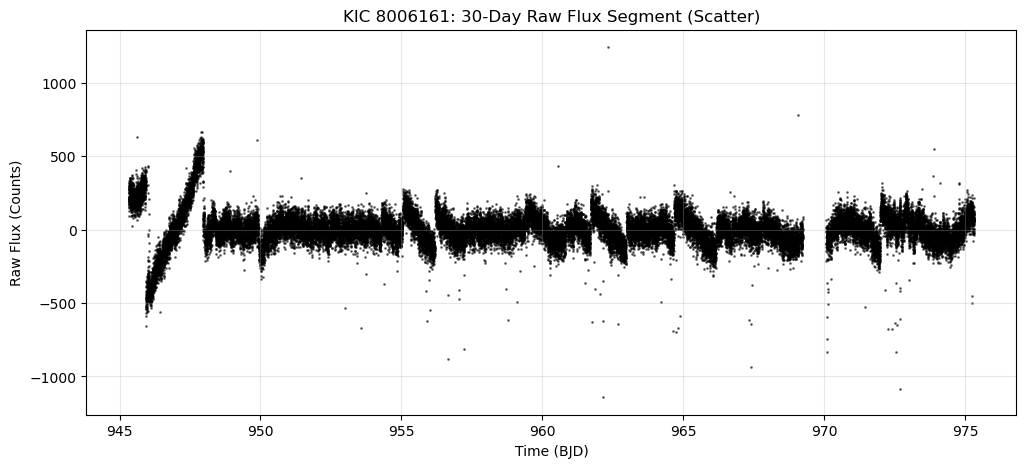

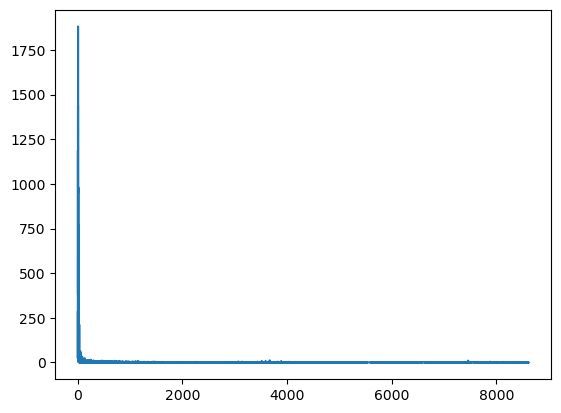

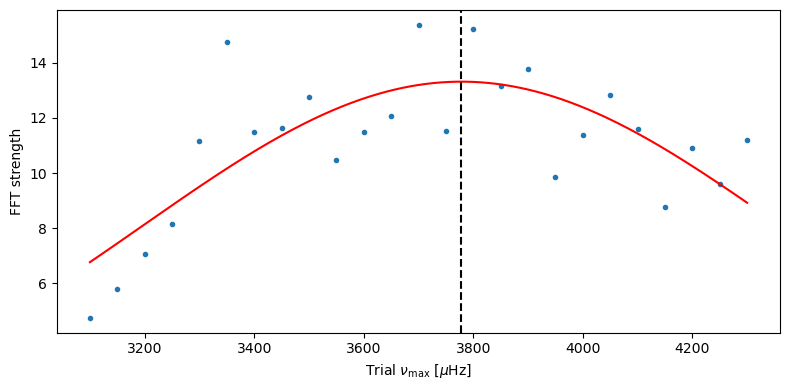

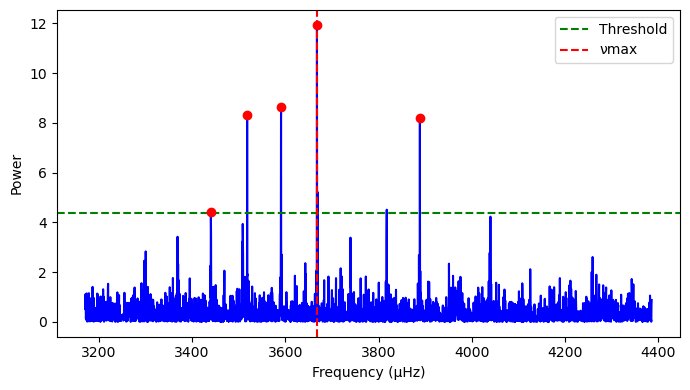

Initial νmax = 3778.4 ± 40.1 µHz
Refined νmax = 3667.8 µHz, Δν = 151.9 µHz


In [58]:
# 1. Define the interval based on your specific requirements
t_start = time[0] + 745
t_end = time[0] + 775

# 2. Create the mask
mask = (time >= t_start) & (time <= t_end)

# 3. Apply mask
time_30d = time[mask]
flux_30d = flux[mask]

# 4. Sort (just in case the file order is causing that negative duration)
sort_idx = np.argsort(time_30d)
time_30d = time_30d[sort_idx]
flux_30d = flux_30d[sort_idx]

# 5. Scatter Plot
plt.figure(figsize=(12, 5))
plt.scatter(time_30d, flux_30d, s=1, color='black', alpha=0.5)

plt.title('KIC 8006161: 30-Day Raw Flux Segment (Scatter)')
plt.xlabel('Time (BJD)')
plt.ylabel('Raw Flux (Counts)')
plt.grid(True, alpha=0.3)
plt.show()

P = psd('mytarget', time=time_30d, flux=flux_30d)
P()

freq = np.array(P.freq)
spectrum = np.array(P.powerdensity) # power density in ppm^/muHz

plt.plot(freq, spectrum)


detected, mu_fit, mu_err, dnu, numax_refined, modes, half_dnu = estimate_numax_dnu(freq, spectrum, np.arange(50,5000,50))

if not detected:
    print("No detection above threshold")
else:
    print(f"Initial νmax = {mu_fit:.1f} ± {mu_err:.1f} µHz")
    print(f"Refined νmax = {numax_refined:.1f} µHz, Δν = {dnu:.1f} µHz")

sig1hr = 61.402669076005054
bgnoise = 27.146071941533187


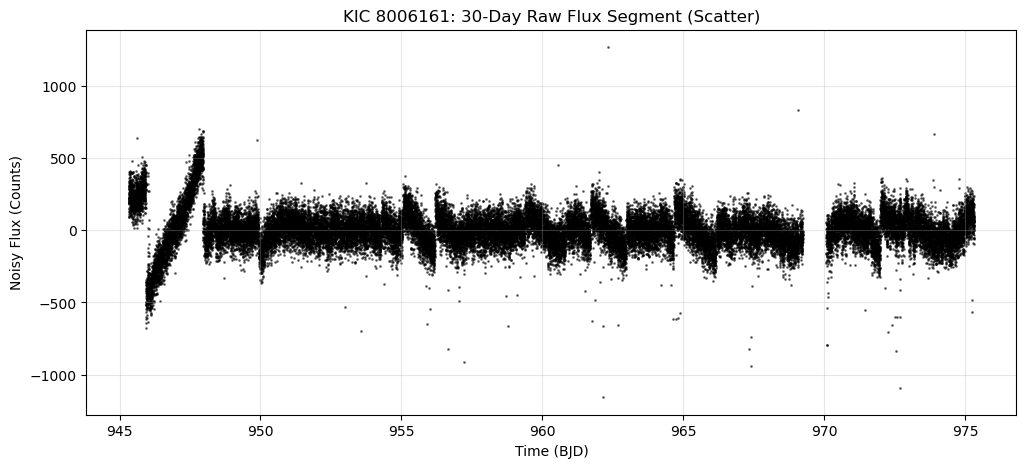

In [132]:

dt = np.median(np.diff(time_30d))  # typical time step in days

points_per_hour = int(1/24 / dt)



# Compute 1-hour RMS using sliding windows
sig1hr_values = []
for i in range(0, len(flux_30d) - points_per_hour + 1, points_per_hour):
    window = flux_30d[i:i+points_per_hour]
    sig1hr_values.append(np.std(window))
    

# Average over all windows
sig1hr= np.mean(sig1hr_values)
print("sig1hr =", sig1hr)

bgnoise = 2.0 * (sig1hr ** 2) * 3600 * 1e-6
print("bgnoise =", bgnoise)



scale = 2  # adjust this
sigma = bgnoise * scale

noise = np.random.normal(0, sigma, len(flux_30d))
flux_noisy = flux_30d + noise


plt.figure(figsize=(12, 5))
plt.scatter(time_30d, flux_noisy, s=1, color='black', alpha=0.5)

plt.title('KIC 8006161: 30-Day Raw Flux Segment (Scatter)')
plt.xlabel('Time (BJD)')
plt.ylabel('Noisy Flux (Counts)')
plt.grid(True, alpha=0.3)
plt.show()




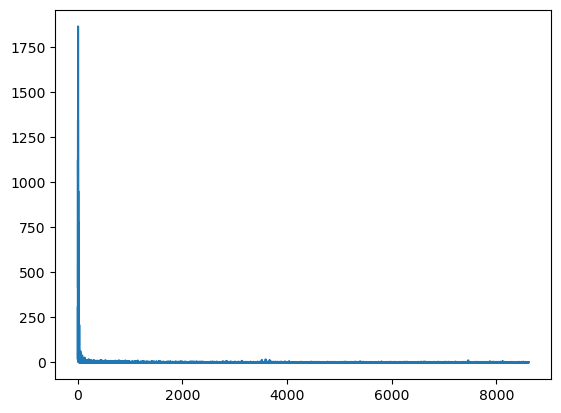

In [133]:
P = psd('mytarget', time=time_30d, flux=flux_noisy)
P()

freq = np.array(P.freq)
spectrum = np.array(P.powerdensity) # power density in ppm^/Hz

plt.plot(freq, spectrum)

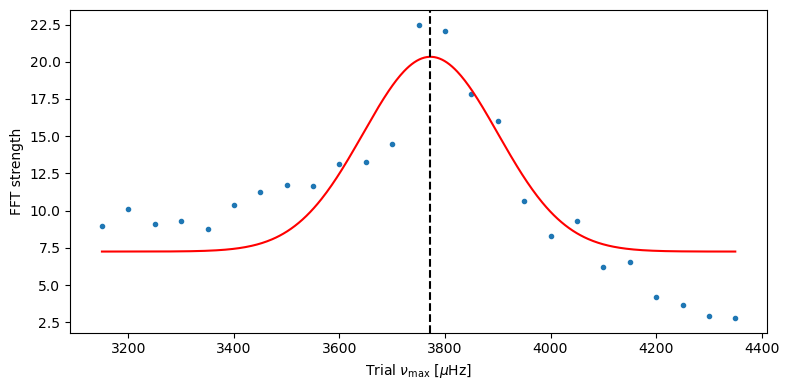

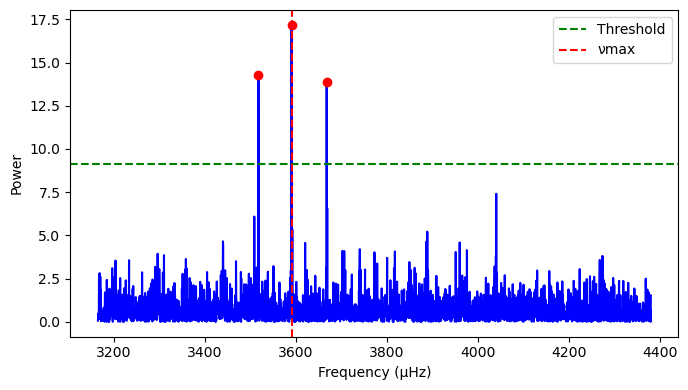

Initial νmax = 3772.5 ± 17.6 µHz
Refined νmax = 3590.7 µHz, Δν = 75.9 µHz


In [134]:

detected, mu_fit, mu_err, dnu, numax_refined, modes, half_dnu = estimate_numax_dnu(freq, spectrum, np.arange(50,5000,50))

if not detected:
    print("No detection above threshold")
else:
    print(f"Initial νmax = {mu_fit:.1f} ± {mu_err:.1f} µHz")
    print(f"Refined νmax = {numax_refined:.1f} µHz, Δν = {dnu:.1f} µHz")